In [1]:
!pip install qiskit qiskit-aer
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 56.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 73.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.4 MB/s eta 0:00:00


In [2]:
def create_bell_pair():
    """
    Returns:
        QuantumCircuit: Circuit that produces a Bell pair
    """
    qc = QuantumCircuit(2)
    qc.h(1)
    qc.cx(1, 0)
    return qc

In [3]:
def encode_message(qc, qubit, msg):
    """Encodes a two-bit message on qc using the superdense coding protocol
    Args:
        qc (QuantumCircuit): Circuit to encode message on
        qubit (int): Which qubit to add the gate to
        msg (str): Two-bit message to send
    Returns:
        QuantumCircuit: Circuit that, when decoded, will produce msg
    Raises:
        ValueError if msg is wrong length or contains invalid characters
    """
    if len(msg) != 2 or not set(msg).issubset({"0","1"}):
        raise ValueError(f"message '{msg}' is invalid")
    if msg[1] == "1":
        qc.x(qubit)
    if msg[0] == "1":
        qc.z(qubit)
    return qc

In [4]:
def decode_message(qc):
    qc.cx(1, 0)
    qc.h(1)
    return qc

In [5]:
# Charlie creates the entangled pair between Alice and Bob
qc = create_bell_pair()

# We'll add a barrier for visual separation
qc.barrier()

# At this point, qubit 0 goes to Alice and qubit 1 goes to Bob

# Next, Alice encodes her message onto qubit 1. In this case,
# we want to send the message '10'. You can try changing this
# value and see how it affects the circuit
message = '10'
qc = encode_message(qc, 1, message)
qc.barrier()
# Alice then sends her qubit to Bob.

# After receiving qubit 0, Bob applies the recovery protocol:
qc = decode_message(qc)

# Finally, Bob measures his qubits to read Alice's message
qc.measure_all()

# Draw our output
qc.draw()

┌───┐ ░       ░ ┌───┐      ░ ┌─┐   
   q_0: ─────┤ X ├─░───────░─┤ X ├──────░─┤M├───
        ┌───┐└─┬─┘ ░ ┌───┐ ░ └─┬─┘┌───┐ ░ └╥┘┌─┐
   q_1: ┤ H ├──■───░─┤ Z ├─░───■──┤ H ├─░──╫─┤M├
        └───┘      ░ └───┘ ░      └───┘ ░  ║ └╥┘
meas: 2/═══════════════════════════════════╩══╩═
                                           0  1

{'10': 1024}


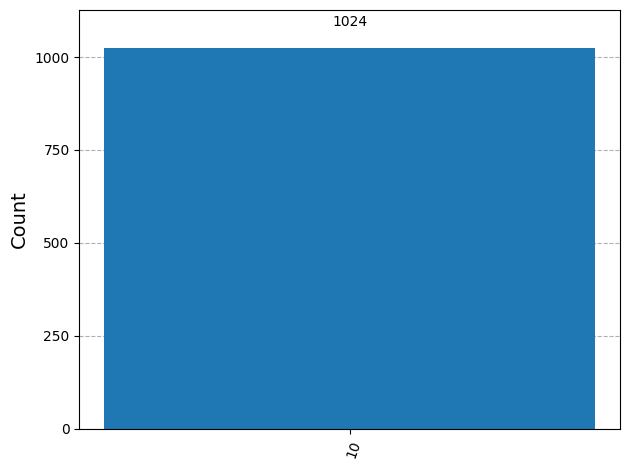

In [6]:
aer_sim = Aer.get_backend('aer_simulator')
result = aer_sim.run(qc).result()
counts = result.get_counts(qc)
print(counts)
plot_histogram(counts)

In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer

qc = QuantumCircuit(2)

qc.h(0)        # Superposition
qc.cx(0, 1)    # Entanglement

qc.measure_all()

backend = Aer.get_backend('aer_simulator')
result = backend.run(transpile(qc, backend), shots=1024).result()

counts = result.get_counts()
print(counts)

{'00': 501, '11': 523}


Counts: {'00': 522, '11': 502}


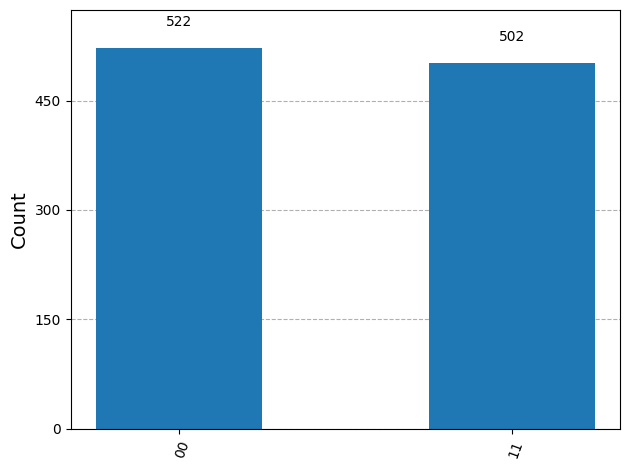

In [8]:
# Install (run once, then restart session)
!pip install qiskit qiskit-aer

# Imports
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Create circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# Add measurement (important)
qc.measure_all()

# Choose simulator backend
backend = Aer.get_backend('aer_simulator')

# Transpile
t_qc = transpile(qc, backend)

# Run job
job = backend.run(t_qc, shots=1024)

# Get result
result = job.result()

# Print counts
counts = result.get_counts()
print("Counts:", counts)

# Plot histogram
plot_histogram(counts)

In [9]:
counts = result.get_counts()
shots = 1024

correct_results = counts.get('00', 0) + counts.get('11', 0)
accuracy = (correct_results / shots) * 100

print("Counts:", counts)
print(f"Accuracy = {accuracy:.2f}%")

Counts: {'00': 522, '11': 502}
Accuracy = 100.00%


In [10]:
import qiskit
print(qiskit.__version__)

2.3.1


TELEPORTATION

In [11]:
!pip install qiskit==1.0.2 qiskit-aer qiskit-ibm-provider

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of qiskit-aer to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of qiskit-aer to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 70.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 78.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.9/249.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 73.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 MB 29.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0

In [12]:
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, plot_bloch_multivector, array_to_latex
from qiskit.circuit.library import Initialize
from qiskit.result import marginal_counts
from qiskit.quantum_info import random_statevector

In [13]:
## SETUP
# Protocol uses 3 qubits and 2 classical bits in 2 different registers

qr = QuantumRegister(3, name="q")    # Protocol uses 3 qubits
crz = ClassicalRegister(1, name="crz") # and 2 classical bits
crx = ClassicalRegister(1, name="crx") # in 2 different registers
teleportation_circuit = QuantumCircuit(qr, crz, crx)

In [14]:
def create_bell_pair(qc, a, b):
    """Creates a bell pair in qc using qubits a & b"""
    qc.h(a) # Put qubit a into state |+>
    qc.cx(a,b) # CNOT with a as control and b as target

In [15]:
## SETUP
# Protocol uses 3 qubits and 2 classical bits in 2 different registers
qr = QuantumRegister(3, name="q")
crz, crx = ClassicalRegister(1, name="crz"), ClassicalRegister(1, name="crx")
teleportation_circuit = QuantumCircuit(qr, crz, crx)

## STEP 1
# In our case, Telamon entangles qubits q1 and q2
# Let's apply this to our circuit:
create_bell_pair(teleportation_circuit, 1, 2)
# And view the circuit so far:
teleportation_circuit.draw()

q_0: ──────────
       ┌───┐     
  q_1: ┤ H ├──■──
       └───┘┌─┴─┐
  q_2: ─────┤ X ├
            └───┘
crz: 1/══════════
                 
crx: 1/══════════

In [16]:
def alice_gates(qc, psi, a):
    qc.cx(psi, a)
    qc.h(psi)

In [17]:
## SETUP
# Protocol uses 3 qubits and 2 classical bits in 2 different registers
qr = QuantumRegister(3, name="q")
crz, crx = ClassicalRegister(1, name="crz"), ClassicalRegister(1, name="crx")
teleportation_circuit = QuantumCircuit(qr, crz, crx)

## STEP 1
create_bell_pair(teleportation_circuit, 1, 2)

## STEP 2
teleportation_circuit.barrier() # Use barrier to separate steps
alice_gates(teleportation_circuit, 0, 1)
teleportation_circuit.draw()

░      ┌───┐
  q_0: ───────────░───■──┤ H ├
       ┌───┐      ░ ┌─┴─┐└───┘
  q_1: ┤ H ├──■───░─┤ X ├─────
       └───┘┌─┴─┐ ░ └───┘     
  q_2: ─────┤ X ├─░───────────
            └───┘ ░           
crz: 1/═══════════════════════
                              
crx: 1/═══════════════════════

In [18]:
def measure_and_send(qc, a, b):
    """Measures qubits a & b and 'sends' the results to Bob"""
    qc.barrier()
    qc.measure(a,0)
    qc.measure(b,1)

In [19]:
## SETUP
# Protocol uses 3 qubits and 2 classical bits in 2 different registers
qr = QuantumRegister(3, name="q")
crz, crx = ClassicalRegister(1, name="crz"), ClassicalRegister(1, name="crx")
teleportation_circuit = QuantumCircuit(qr, crz, crx)

## STEP 1
create_bell_pair(teleportation_circuit, 1, 2)

## STEP 2
teleportation_circuit.barrier() # Use barrier to separate steps
alice_gates(teleportation_circuit, 0, 1)

## STEP 3
measure_and_send(teleportation_circuit, 0 ,1)
teleportation_circuit.draw()

░      ┌───┐ ░ ┌─┐   
  q_0: ───────────░───■──┤ H ├─░─┤M├───
       ┌───┐      ░ ┌─┴─┐└───┘ ░ └╥┘┌─┐
  q_1: ┤ H ├──■───░─┤ X ├──────░──╫─┤M├
       └───┘┌─┴─┐ ░ └───┘      ░  ║ └╥┘
  q_2: ─────┤ X ├─░────────────░──╫──╫─
            └───┘ ░            ░  ║  ║ 
crz: 1/═══════════════════════════╩══╬═
                                  0  ║ 
crx: 1/══════════════════════════════╩═
                                     0

In [39]:
def bob_gates(qc, qubit, crz, crx):
    # Apply X if crx == 1
    with qc.if_test((crx, 1)):
        qc.x(qubit)

    # Apply Z if crz == 1
    with qc.if_test((crz, 1)):
        qc.z(qubit)

In [21]:
!pip install --upgrade --force-reinstall pylatexenc matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 92.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 86.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 76.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 96.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 k

In [22]:
import pylatexenc
print("pylatexenc installed ✅")

pylatexenc installed ✅


In [41]:
# -----------------------------
# SETUP
# -----------------------------
qr = QuantumRegister(3, name="q")
crz = ClassicalRegister(1, name="crz")
crx = ClassicalRegister(1, name="crx")
teleportation_circuit = QuantumCircuit(qr, crz, crx)

# -----------------------------
# STEP 1: Create Bell pair
# -----------------------------
create_bell_pair(teleportation_circuit, 1, 2)

# -----------------------------
# STEP 2: Alice applies gates
# -----------------------------
teleportation_circuit.barrier()
alice_gates(teleportation_circuit, 0, 1)

# -----------------------------
# STEP 3: Measure and send
# -----------------------------
measure_and_send(teleportation_circuit, 0, 1, crz, crx) 

# -----------------------------
# STEP 4: Bob applies gates
# -----------------------------
teleportation_circuit.barrier()
bob_gates(teleportation_circuit, 2, crz, crx)

# -----------------------------
# Draw the circuit
# -----------------------------
teleportation_circuit.draw('text')

░      ┌───┐ ░ ┌─┐    ░                                     »
  q_0: ───────────░───■──┤ H ├─░─┤M├────░─────────────────────────────────────»
       ┌───┐      ░ ┌─┴─┐└───┘ ░ └╥┘┌─┐ ░                                     »
  q_1: ┤ H ├──■───░─┤ X ├──────░──╫─┤M├─░─────────────────────────────────────»
       └───┘┌─┴─┐ ░ └───┘      ░  ║ └╥┘ ░ ┌────── ┌───┐ ───────┐ ┌────── ┌───┐»
  q_2: ─────┤ X ├─░────────────░──╫──╫──░─┤ If-0  ┤ X ├  End-0 ├─┤ If-0  ┤ Z ├»
            └───┘ ░            ░  ║  ║  ░ └──╥─── └───┘ ───────┘ └──╥─── └───┘»
                                  ║  ║       ║                   ┌──╨──┐      »
crz: 1/═══════════════════════════╩══╬═══════╬═══════════════════╡ 0x1 ╞══════»
                                  0  ║    ┌──╨──┐                └─────┘      »
crx: 1/══════════════════════════════╩════╡ 0x1 ╞═════════════════════════════»
                                     0    └─────┘                             »
«                 
«  q_0: ──────────
«                 
«  q_1: ──────────
«        ───────┐ 
«  q_2:   End-0 ├─
«        ───────┘ 
«crz: 1/══════════
«                 
«crx: 1/══════════
«

<IPython.core.display.Latex object>

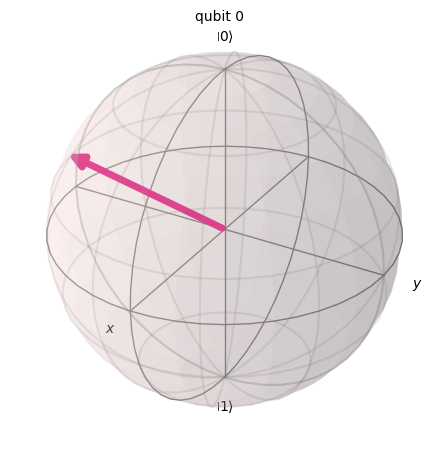

In [47]:
# Create random 1-qubit state
psi = random_statevector(2)

# Display it nicely
display(array_to_latex(psi, prefix="|\\psi\\rangle ="))
# Show it on a Bloch sphere
plot_bloch_multivector(psi)

In [48]:
init_gate = Initialize(psi)
init_gate.label = "init"

In [49]:
qr = QuantumRegister(3, name="q")
crz = ClassicalRegister(1, name="crz")
crx = ClassicalRegister(1, name="crx")
qc = QuantumCircuit(qr, crz, crx)

## STEP 0
qc.append(init_gate, [0])
qc.barrier()

## STEP 1
create_bell_pair(qc, 1, 2)
qc.barrier()

## STEP 2
alice_gates(qc, 0, 1)

## STEP 3 
measure_and_send(qc, 0, 1, crz, crx)

## STEP 4
bob_gates(qc, 2, crz, crx)

qc.draw()

┌─────────────────────────────────────────┐ ░            ░      ┌───┐ ░ »
  q_0: ┤ init(-0.43876+0.69806j,0.3856+0.41414j) ├─░────────────░───■──┤ H ├─░─»
       └─────────────────────────────────────────┘ ░ ┌───┐      ░ ┌─┴─┐└───┘ ░ »
  q_1: ────────────────────────────────────────────░─┤ H ├──■───░─┤ X ├──────░─»
                                                   ░ └───┘┌─┴─┐ ░ └───┘      ░ »
  q_2: ────────────────────────────────────────────░──────┤ X ├─░────────────░─»
                                                   ░      └───┘ ░            ░ »
crz: 1/════════════════════════════════════════════════════════════════════════»
                                                                               »
crx: 1/════════════════════════════════════════════════════════════════════════»
                                                                               »
«       ┌─┐                                                 
«  q_0: ┤M├─────────────────────────────────────────────────
«       └╥┘┌─┐                                              
«  q_1: ─╫─┤M├──────────────────────────────────────────────
«        ║ └╥┘┌────── ┌───┐ ───────┐ ┌────── ┌───┐ ───────┐ 
«  q_2: ─╫──╫─┤ If-0  ┤ X ├  End-0 ├─┤ If-0  ┤ Z ├  End-0 ├─
«        ║  ║ └──╥─── └───┘ ───────┘ └──╥─── └───┘ ───────┘ 
«        ║  ║    ║                   ┌──╨──┐                
«crz: 1/═╩══╬════╬═══════════════════╡ 0x1 ╞════════════════
«        0  ║ ┌──╨──┐                └─────┘                
«crx: 1/════╩═╡ 0x1 ╞═══════════════════════════════════════
«           0 └─────┘

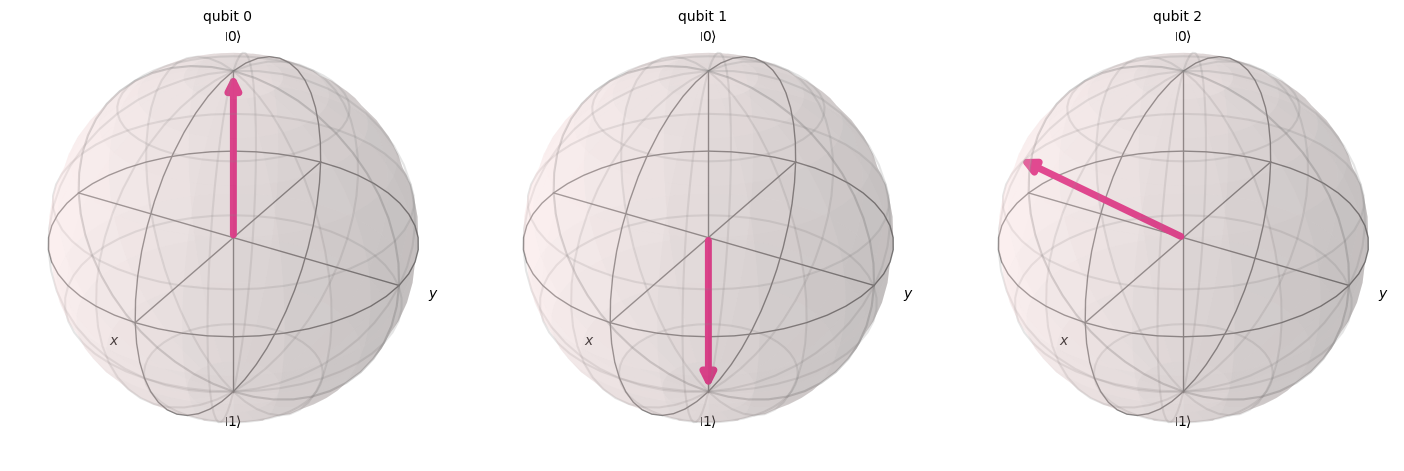

In [50]:
sim = Aer.get_backend('aer_simulator')
qc.save_statevector()
out_vector = sim.run(qc).result().get_statevector()
plot_bloch_multivector(out_vector)

In [51]:
inverse_init_gate = init_gate.gates_to_uncompute()

In [52]:
## SETUP
qr = QuantumRegister(3, name="q")
crz = ClassicalRegister(1, name="crz")
crx = ClassicalRegister(1, name="crx")
qc = QuantumCircuit(qr, crz, crx)

## STEP 0
qc.append(init_gate, [0])
qc.barrier()

## STEP 1
create_bell_pair(qc, 1, 2)
qc.barrier()

## STEP 2
alice_gates(qc, 0, 1)

## STEP 3 ✅ FIXED
measure_and_send(qc, 0, 1, crz, crx)

## STEP 4
bob_gates(qc, 2, crz, crx)

## STEP 5
qc.append(inverse_init_gate, [2])

qc.draw()

┌─────────────────────────────────────────┐ ░            ░      ┌───┐ ░ »
  q_0: ┤ init(-0.43876+0.69806j,0.3856+0.41414j) ├─░────────────░───■──┤ H ├─░─»
       └─────────────────────────────────────────┘ ░ ┌───┐      ░ ┌─┴─┐└───┘ ░ »
  q_1: ────────────────────────────────────────────░─┤ H ├──■───░─┤ X ├──────░─»
                                                   ░ └───┘┌─┴─┐ ░ └───┘      ░ »
  q_2: ────────────────────────────────────────────░──────┤ X ├─░────────────░─»
                                                   ░      └───┘ ░            ░ »
crz: 1/════════════════════════════════════════════════════════════════════════»
                                                                               »
crx: 1/════════════════════════════════════════════════════════════════════════»
                                                                               »
«       ┌─┐                                                 »
«  q_0: ┤M├─────────────────────────────────────────────────»
«       └╥┘┌─┐                                              »
«  q_1: ─╫─┤M├──────────────────────────────────────────────»
«        ║ └╥┘┌────── ┌───┐ ───────┐ ┌────── ┌───┐ ───────┐ »
«  q_2: ─╫──╫─┤ If-0  ┤ X ├  End-0 ├─┤ If-0  ┤ Z ├  End-0 ├─»
«        ║  ║ └──╥─── └───┘ ───────┘ └──╥─── └───┘ ───────┘ »
«        ║  ║    ║                   ┌──╨──┐                »
«crz: 1/═╩══╬════╬═══════════════════╡ 0x1 ╞════════════════»
«        0  ║ ┌──╨──┐                └─────┘                »
«crx: 1/════╩═╡ 0x1 ╞═══════════════════════════════════════»
«           0 └─────┘                                       »
«                                
«  q_0: ─────────────────────────
«                                
«  q_1: ─────────────────────────
«       ┌───────────────────────┐
«  q_2: ┤ isometry_to_uncompute ├
«       └───────────────────────┘
«crz: 1/═════════════════════════
«                                
«crx: 1/═════════════════════════
«

In [53]:
# Need to add a new ClassicalRegister
# to see the result
cr_result = ClassicalRegister(1)
qc.add_register(cr_result)
qc.measure(2,2)
qc.draw()

┌─────────────────────────────────────────┐ ░            ░      ┌───┐ ░ »
  q_0: ┤ init(-0.43876+0.69806j,0.3856+0.41414j) ├─░────────────░───■──┤ H ├─░─»
       └─────────────────────────────────────────┘ ░ ┌───┐      ░ ┌─┴─┐└───┘ ░ »
  q_1: ────────────────────────────────────────────░─┤ H ├──■───░─┤ X ├──────░─»
                                                   ░ └───┘┌─┴─┐ ░ └───┘      ░ »
  q_2: ────────────────────────────────────────────░──────┤ X ├─░────────────░─»
                                                   ░      └───┘ ░            ░ »
crz: 1/════════════════════════════════════════════════════════════════════════»
                                                                               »
crx: 1/════════════════════════════════════════════════════════════════════════»
                                                                               »
 c0: 1/════════════════════════════════════════════════════════════════════════»
                                                                               »
«       ┌─┐                                                 »
«  q_0: ┤M├─────────────────────────────────────────────────»
«       └╥┘┌─┐                                              »
«  q_1: ─╫─┤M├──────────────────────────────────────────────»
«        ║ └╥┘┌────── ┌───┐ ───────┐ ┌────── ┌───┐ ───────┐ »
«  q_2: ─╫──╫─┤ If-0  ┤ X ├  End-0 ├─┤ If-0  ┤ Z ├  End-0 ├─»
«        ║  ║ └──╥─── └───┘ ───────┘ └──╥─── └───┘ ───────┘ »
«        ║  ║    ║                   ┌──╨──┐                »
«crz: 1/═╩══╬════╬═══════════════════╡ 0x1 ╞════════════════»
«        0  ║ ┌──╨──┐                └─────┘                »
«crx: 1/════╩═╡ 0x1 ╞═══════════════════════════════════════»
«           0 └─────┘                                       »
« c0: 1/════════════════════════════════════════════════════»
«                                                           »
«                                   
«  q_0: ────────────────────────────
«                                   
«  q_1: ────────────────────────────
«       ┌───────────────────────┐┌─┐
«  q_2: ┤ isometry_to_uncompute ├┤M├
«       └───────────────────────┘└╥┘
«crz: 1/══════════════════════════╬═
«                                 ║ 
«crx: 1/══════════════════════════╬═
«                                 ║ 
« c0: 1/══════════════════════════╩═
«                                 0

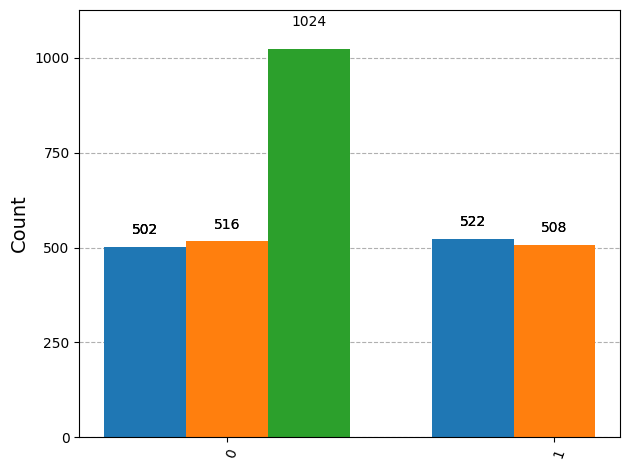

In [54]:
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts

qc = qc.decompose(reps=5)

sim = Aer.get_backend('aer_simulator')

result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

qubit_counts = [marginal_counts(counts, [i]) for i in range(3)]

plot_histogram(qubit_counts)

In [55]:
def new_bob_gates(qc, a, b, c):
    qc.cx(b, c)
    qc.cz(a, c)

In [56]:
qc = QuantumCircuit(3,1)

# First, let's initialize Alice's q0
qc.append(init_gate, [0])
qc.barrier()

# Now begins the teleportation protocol
create_bell_pair(qc, 1, 2)
qc.barrier()
# Send q1 to Alice and q2 to Bob
alice_gates(qc, 0, 1)
qc.barrier()
# Alice sends classical bits to Bob
new_bob_gates(qc, 0, 1, 2)

# We undo the initialization process
qc.append(inverse_init_gate, [2])

# See the results, we only care about the state of qubit 2
qc.measure(2,0)

# View the results:
qc.draw()

┌─────────────────────────────────────────┐ ░            ░      ┌───┐ ░ »
q_0: ┤ init(-0.43876+0.69806j,0.3856+0.41414j) ├─░────────────░───■──┤ H ├─░─»
     └─────────────────────────────────────────┘ ░ ┌───┐      ░ ┌─┴─┐└───┘ ░ »
q_1: ────────────────────────────────────────────░─┤ H ├──■───░─┤ X ├──────░─»
                                                 ░ └───┘┌─┴─┐ ░ └───┘      ░ »
q_2: ────────────────────────────────────────────░──────┤ X ├─░────────────░─»
                                                 ░      └───┘ ░            ░ »
c: 1/════════════════════════════════════════════════════════════════════════»
                                                                             »
«                                         
«q_0: ──────■─────────────────────────────
«           │                             
«q_1: ──■───┼─────────────────────────────
«     ┌─┴─┐ │ ┌───────────────────────┐┌─┐
«q_2: ┤ X ├─■─┤ isometry_to_uncompute ├┤M├
«     └───┘   └───────────────────────┘└╥┘
«c: 1/══════════════════════════════════╩═
«                                       0

In [57]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import ipywidgets as widgets
from IPython.display import display

# UI Elements
button_p = widgets.Button(description='Play')
gate_p = widgets.Dropdown(
    options=[('Identity', 'i'), ('Bit Flip', 'x')],
    description='Choice: '
)
out_p = widgets.Output()

def on_button_clicked(b):
    with out_p:
        out_p.clear_output()
        
        # Quantum circuit
        qr = QuantumRegister(1)
        cr = ClassicalRegister(1)
        qc = QuantumCircuit(qr, cr)
        
        # Turn 1: Hadamard
        qc.h(qr[0])
        
        # Turn 2: Player choice
        if gate_p.value == 'i':
            qc.id(qr[0])
        elif gate_p.value == 'x':
            qc.x(qr[0])
        
        # Turn 3: Hadamard
        qc.h(qr[0])
        
        # Measurement
        qc.measure(qr, cr)
        
        # Aer simulation — NO transpile needed!
        backend = Aer.get_backend('aer_simulator')
        job = backend.run(qc, shots=8192)
        result = job.result()
        counts = result.get_counts()
        
        # Output
        print("Counts:", counts)
        if counts.get('0', 0) == 8192:
            print("You Lose to Quantum. Quantum Computer Wins 😢")
        elif counts.get('1', 0) == 8192:
            print("You Win against Quantum Computer 🎉")
        else:
            print("Quantum randomness decides the outcome ⚡")
        
        plot_histogram(counts)

button_p.on_click(on_button_clicked)
display(widgets.VBox([gate_p, button_p, out_p]))